# Import statements

In [35]:
import pickle
import numpy as np
import pandas as pd

In [36]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from xgboost import plot_importance
from matplotlib import pyplot

In [37]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [4]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

In [5]:
from platform import python_version

print(python_version())



3.10.12


In [6]:
!which python3

/usr/bin/python3


In [7]:
print(np.__version__)

1.26.3


# Define all functions

In [8]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(1, 10),
        'max_depth': Integer(1, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}
 

In [9]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [10]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=24, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=6
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [11]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [12]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [13]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = [x for x in best_model.predict(X_holdout)]

    # Compute performance metrics
    ss = sqrt(mean_squared_error(all_preds, y_holdout))
    rr = r2_score(all_preds, y_holdout)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100

    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")

    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    plot_x, plot_y = [], []

    for counter, actual in enumerate(y_holdout):
        if counter <= 5:  # Print first 5 examples
            print(counter, actual, all_preds[counter])
        if all_preds[counter] > 1:
            plot_x.append(actual)
            plot_y.append(all_preds[counter])

    # Create a DataFrame for plotting
    thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()


    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [14]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# XGBoost feature selection

In [15]:
tt_data = pd.read_pickle("pickle_files/training_data_md.pkl")
tt_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,s100,0,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,s1019,0,0,0,0,0,0,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [16]:
tt_bbd_snps = tt_data.iloc[:, 1:251229]
tt_bbd_snps.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1019_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [17]:
tt_bbd_snps_dupe = tt_data.iloc[:, 1:251229]
tt_bbd_snps_dupe.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1019_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [18]:
tt_y = tt_data.iloc[:, 251241:]
tt_y.head()

,MD
new_line,
s100_BeiJing_2013,155.0
s100_HeNan_2015,115.0
s1014_HeNan_2014,108.0
s1014_HeNan_2015,104.0
s1019_HeNan_2015,113.0


In [19]:
cov = tt_data.iloc[:,-12:]
cov.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,
s100_BeiJing_2013,9.5000,6.26667,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,10.2133,4.00000,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,11.8200,7.78667,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,13.2800,6.94667,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,10.8400,7.34667,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(tt_bbd_snps, tt_y, test_size=0.1, random_state=42)

In [ ]:
#Ran this is an isolated high mem job and got the bets params
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

In [20]:
best_params = {
    'colsample_bylevel': 0.015534097186469031,
    'colsample_bytree': 0.01,
    'gamma': 0.00018697385296177117,
    'learning_rate': 0.01,
    'max_delta_step': 0,
    'max_depth': 0,
    'min_child_weight': 10,
    'n_estimators': 198,
    'reg_alpha': 1.0,
    'reg_lambda': 1e-09,
    'subsample': 0.18897405861906463
}

# Run the model with the best parameters
model = xgb.XGBRegressor(**best_params)

In [21]:
#tt_bbd_snps = tt_bbd_snps.to_numpy()
#tt_y = tt_y.to_numpy() 
#Fit the modle on the entire training training set
model.fit(tt_bbd_snps, tt_y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.015534097186469031, colsample_bynode=None,
             colsample_bytree=0.01, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.00018697385296177117,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=0,
             max_depth=0, max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=198,
             n_jobs=None, num_parallel_tree=None, ...)

In [31]:
#if you wan tto use the default feature importance
importances = model.feature_importances_
print(importances)
print("Median importance:", np.median(importances))
print("Features kept:", selector.get_support().sum(), "out of", len(importances))

[0. 0. 0. ... 0. 0. 0.]
Median importance: 0.0
Features kept: 251228 out of 251228


<Figure size 2000x2000 with 0 Axes>

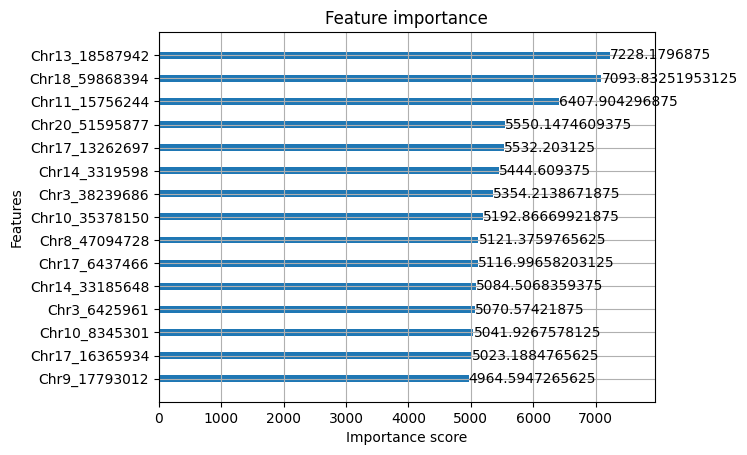

In [22]:
plt.figure(figsize = (20, 20))
plot_importance(model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

In [23]:
booster = model.get_booster()
importances = booster.get_score(importance_type='gain')
feature_names = booster.feature_names
importances_array = np.array([importances.get(f, 0.) for f in feature_names])

In [24]:
importances_array

array([0., 0., 0., ..., 0., 0., 0.])

In [25]:
print("Max importance:", np.max(importances_array))
print("Min importance:", np.min(importances_array))
print("Mean importance:", np.mean(importances_array))
print("Median importance:", np.median(importances_array))

Max importance: 7228.1796875
Min importance: 0.0
Mean importance: 28.92120808609986
Median importance: 0.0


In [26]:
print("Features with gain > 0:", np.sum(importances_array > 0))
print("Features with gain > mean:", np.sum(importances_array > np.mean(importances_array)))
print("Features with gain > 20:", np.sum(importances_array > 2000))

Features with gain > 0: 6195
Features with gain > mean: 6131
Features with gain > 20: 953


In [27]:
top_n = 1000 # Choose a number based on the max value and median values from abive
top_indices = np.argsort(importances_array)[::-1][:top_n]  # Sort in descending order and take first 1000
selected_features = np.array(feature_names)[top_indices]
new_data = tt_bbd_snps[selected_features]

In [155]:
# If using a threshold like mean or median or a custom thresold then use this
threshold = np.mean(importances_array)
selected_mask = importances_array > threshold
selected_features = np.array(feature_names)[selected_mask]
new_data = tt_bbd_snps[selected_features]

In [28]:
new_data.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr20_32404414,Chr14_11784839,Chr1_15174358,Chr16_37617327,Chr14_32962588,Chr18_45197353,Chr17_20583513,Chr3_40105409,Chr4_35874454,Chr12_16805346
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,1,0,0,0,0,1,0,0,0,2,...,0,2,0,1,0,0,1,1,0,0
s100_HeNan_2015,1,0,0,0,0,1,0,0,0,2,...,0,2,0,1,0,0,1,1,0,0
s1014_HeNan_2014,0,1,0,0,0,0,0,2,2,0,...,0,2,2,0,0,1,0,0,0,0
s1014_HeNan_2015,0,1,0,0,0,0,0,2,2,0,...,0,2,2,0,0,1,0,0,0,0
s1019_HeNan_2015,0,0,0,1,0,0,0,0,1,0,...,0,2,0,1,0,0,0,0,0,2


In [24]:
# Select important features and tranform (can't use this, as it use weight as importance type)
selector = SelectFromModel(model, prefit=True, threshold='median')
X_selected = selector.transform(tt_bbd_snps)

/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [25]:
# Get the names of the selected features
selected_features = tt_bbd_snps.columns[selector.get_support()]

In [29]:
# Create a new df with only the selected features
new_data = pd.DataFrame(X_selected, columns=selected_features, index=tt_bbd_snps.index)

In [157]:
new_data.head()

,Chr1_241970,Chr1_1444930,Chr1_1945717,Chr1_3234577,Chr1_3445775,Chr1_3504427,Chr1_7977377,Chr1_9872220,Chr1_10203439,Chr1_11136926,...,Chr20_35671210,Chr20_36007112,Chr20_38952655,Chr20_39880849,Chr20_40457173,Chr20_42887442,Chr20_44416558,Chr20_44426687,Chr20_47728999,Chr20_50892784
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,1,0,0,0,0,0,0,0,0,0,...,0,0,2,2,0,0,0,0,0,0
s100_HeNan_2014,1,0,0,0,0,0,0,0,0,0,...,0,0,2,2,0,0,0,0,0,0
s100_HeNan_2015,1,0,0,0,0,0,0,0,0,0,...,0,0,2,2,0,0,0,0,0,0
s1014_BeiJing_2013,0,0,0,0,2,0,2,0,0,0,...,0,1,0,0,0,2,0,2,1,0
s1014_HeNan_2014,0,0,0,0,2,0,2,0,0,0,...,0,1,0,0,0,2,0,2,1,0


In [29]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 1000 entries, Chr13_18587942 to Chr12_16805346
dtypes: int64(1000)
memory usage: 18.8+ MB


In [30]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,1,0,0,0,0,1,0,0,0,2,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,1,0,0,0,0,1,0,0,0,2,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,0,1,0,0,0,0,0,2,2,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,0,1,0,0,0,0,0,2,2,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,0,0,0,1,0,0,0,0,1,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [31]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 1012 entries, Chr13_18587942 to MD
dtypes: float64(5), int64(1007)
memory usage: 18.9+ MB


In [32]:
fs_data['Line'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Line')
fs_data.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,0,0,0,0,1,0,0,0,2,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,0,1,0,0,0,0,0,2,2,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,1,0,0,0,0,0,2,2,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,0,0,0,1,0,0,0,0,1,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [33]:
fs_data.to_pickle("fs_md_xgboost_training_data.pkl")

# All covariates

In [38]:
tt_data = pd.read_pickle("fs_md_xgboost_training_data.pkl")
tt_data.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,0,0,0,0,1,0,0,0,2,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,0,1,0,0,0,0,0,2,2,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,1,0,0,0,0,0,2,2,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,0,0,0,1,0,0,0,0,1,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [39]:
tt_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 1012 entries, Chr13_18587942 to MD
dtypes: float64(5), int64(1007)
memory usage: 18.9+ MB


In [40]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,MD
Line,
s100,155.0
s100,115.0
s1014,108.0
s1014,104.0
s1019,113.0


In [42]:
tt_all= tt_data.drop(['MD'], axis=1)
tt_all.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,0,0,0,1,0,0,0,2,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,7.34667,61.0,4.60000,0,0,1,0,0,0,1


In [43]:
tt_all_dupe= tt_data.drop(['MD'], axis=1)
tt_all_dupe.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,0,0,0,1,0,0,0,2,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,7.34667,61.0,4.60000,0,0,1,0,0,0,1


# Run models

In [44]:
X_train, X_test, y_train, y_test = train_test_split(tt_all, tt_y, test_size=0.1, random_state=42)

In [45]:
X_train.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,0,0,0,0,0,0,1,1,0,...,6.55333,77.6,1.2,0,1,0,0,0,1,0
s2863,0,0,0,0,0,0,0,1,1,0,...,6.58000,92.0,2.6,0,0,1,0,0,1,0
s308,0,1,0,0,0,0,0,2,0,0,...,7.44000,104.0,5.0,0,1,0,0,0,0,1
s2023,0,0,0,0,0,2,0,0,1,0,...,4.17333,47.0,3.8,0,0,1,0,0,1,0
s614,0,0,0,0,0,0,0,0,0,0,...,6.58667,86.0,3.4,0,1,0,0,0,1,0


In [46]:
X_train = X_train.to_numpy()

In [47]:
y_train = y_train.to_numpy()

In [48]:
print("Any NaN in y:", np.isnan(y_train).any())
print("Any inf in y:", np.isinf(y_train).any())
print("Max value in y:", np.max(y_train))
print("Any NaN in X:", np.isnan(X_train).any())
print("Any inf in X:", np.isinf(X_train).any())

Any NaN in y: False
Any inf in y: False
Max value in y: 169.0
Any NaN in X: False
Any inf in X: False


In [49]:
print(y_train.dtype)

float64


In [50]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.9923710598637134), ('colsample_bytree', 0.7691228483798597), ('gamma', 2.3975408555863217e-06), ('learning_rate', 0.16392378219983655), ('max_delta_step', 3), ('max_depth', 3), ('min_child_weight', 7), ('n_estimators', 173), ('reg_alpha', 5.907964597205955e-07), ('reg_lambda', 8.231447520498255e-07), ('subsample', 0.6076467700135751)])


In [51]:
tt_all = tt_all.to_numpy()
tt_y = tt_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, tt_all, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.636703245691997
RMSE for dataset is:9.455030924492833& mean of this fold is 114.46938775510205
this is 8.259877256198052% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6365855616290313
RMSE for dataset is:9.519217220703782& mean of this fold is 116.37346938775511
this is 8.179886077801681% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6888495584681528
RMSE for dataset is:9.135671207132324& mean of this fold is 115.97142857142858
this is 7.877518902429942% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7003149460270388
RMSE for dataset is:9.095753712891785& mean of this fold is 116.87346938775511
this is 7.782564991473379% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6992150391772678
RMSE for datase

In [52]:
pickle.dump(best_xgbr_model, open("xgboost_allfeats_xgbr_Md.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top1_allfeats_xgbr_bbd.pickle.dat", "rb"))

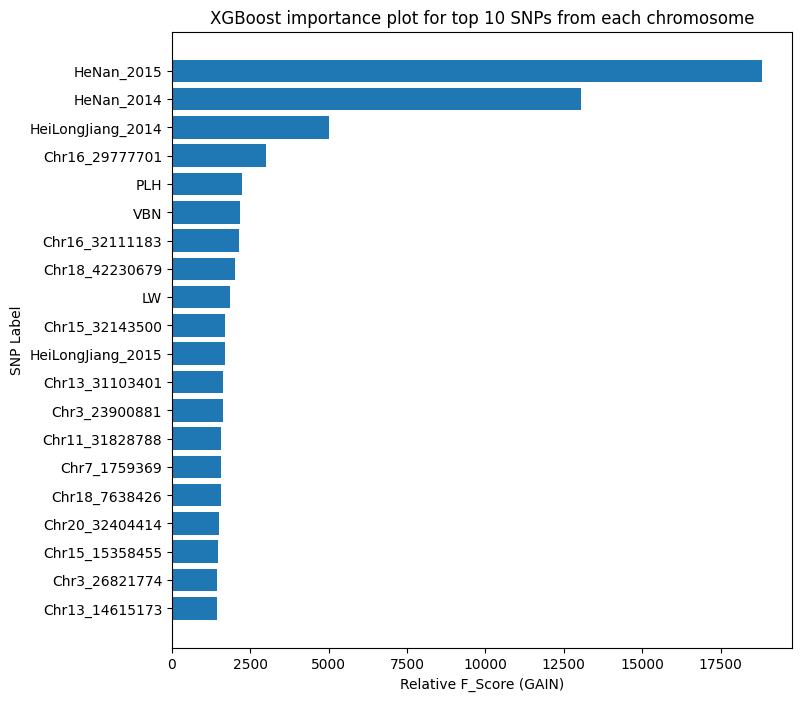

In [53]:
f_names = ['f' + str(i) for i in range(len(tt_all_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[tt_all_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome.png')

In [54]:
explainer = shap.Explainer(best_xgbr_model)

In [55]:
shap_values = explainer(tt_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

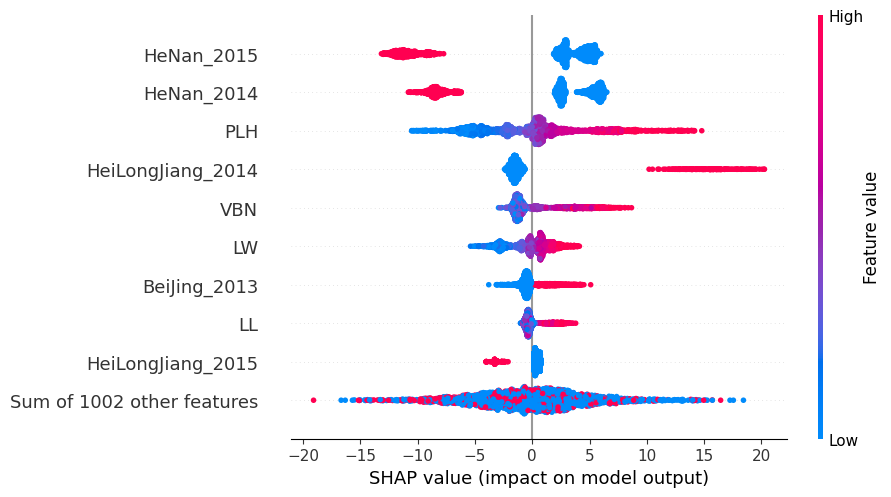

In [56]:
shap.plots.beeswarm(shap_values, show=False)

In [58]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [59]:
holdout_data = holdout_data.set_index('Line')

In [60]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [61]:
X_holdout = holdout_data.iloc[:, 0:251240]

In [62]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [63]:
y_holdout = holdout_data.iloc[:, 251240:]

In [64]:
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [65]:
# Ensure both trainjg and holdout datasets have the same columns
tt_all_dupe, X_holdout = tt_all_dupe.align(X_holdout, join='inner', axis=1)

In [66]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 1011 entries, Chr13_18587942 to landrace
dtypes: float64(4), int64(1007)
memory usage: 4.7+ MB


In [67]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.64
RMSE of Holdout: 9.68
Mean of Holdout: 117.42
This is 8.25% of the mean pheno data
0 117.0 117.93975
1 148.0 148.72626
2 117.0 113.54933
3 121.0 116.72839
4 119.0 115.83622
5 94.0 97.02298


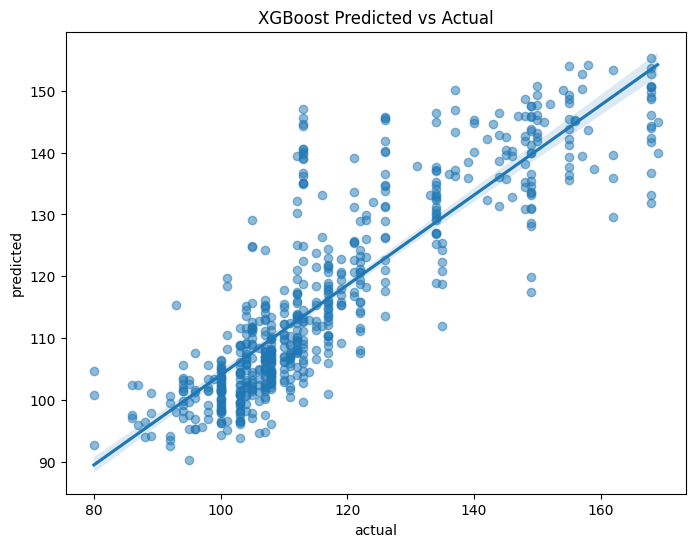

In [68]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [69]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 117.0 117.93975
1 148.0 148.72626
2 117.0 113.54933
3 121.0 116.72839
4 119.0 115.83622
5 94.0 97.02298


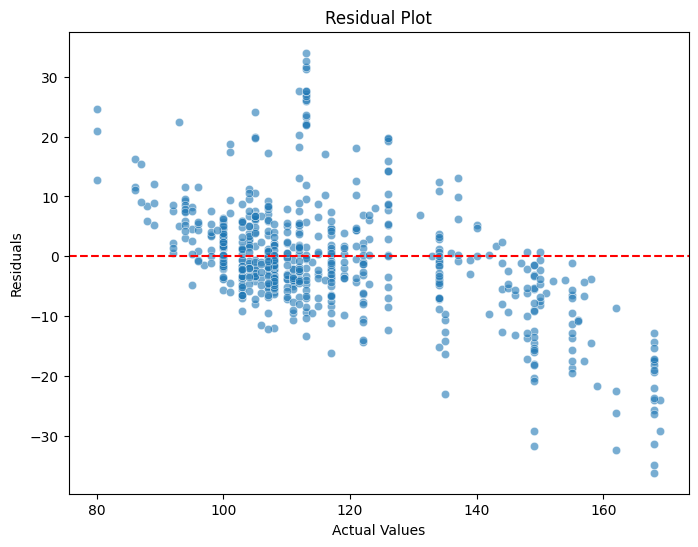

In [70]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [71]:
#### RF models

In [72]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 24), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [73]:
#gwas_all = gwas_all.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, tt_all, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.9993993756498338
RMSE for dataset is:14.983276836812792& mean of this fold is 117.67755102040816
this is 12.732485258989055% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.4030180247525639
RMSE for dataset is:13.731569192206303& mean of this fold is 116.43265306122449
this is 11.793572362373078% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.6076481626893693
RMSE for dataset is:13.8980500469126& mean of this fold is 117.34285714285714
this is 11.843967656243997% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.1585424882413484
RMSE for dataset is:13.142818781938754& mean of this fold is 114.81224489795919
this is 11.447227422144387% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.8142820648726539
RMS

In [74]:
pickle.dump(best_rfr_model, open("xgboost_allfeats_rfr_md.pickle.dat", "wb"))

R^2 Value of Holdout: -1.58
RMSE of Holdout: 14.00
Mean of Holdout: 117.42
This is 11.93% of the mean pheno data
0 117.0 119.91172893772894
1 148.0 126.09395238095239
2 117.0 114.773875
3 121.0 128.97583333333333
4 119.0 130.3885
5 94.0 108.774


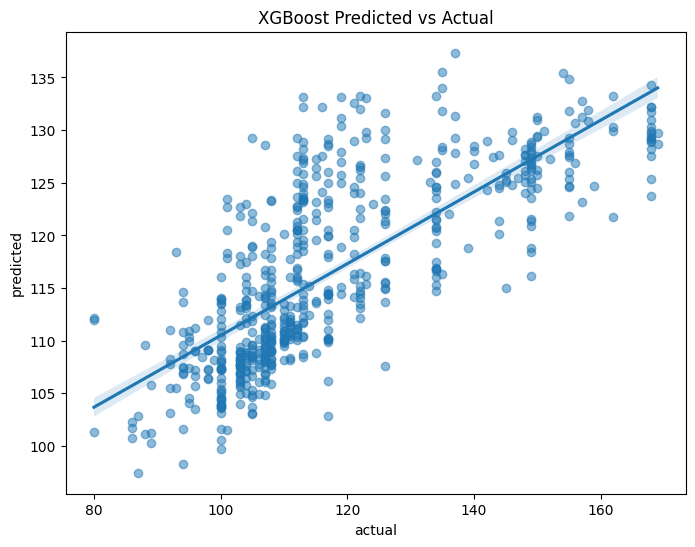

In [75]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [76]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [77]:
best_svr_model = eval_k_fold(best_svreg, tt_all, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4860588270084557
RMSE for dataset is:12.713677228855277& mean of this fold is 115.10612244897959
this is 11.045178969077488% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6673490426434701
RMSE for dataset is:10.13758070672914& mean of this fold is 116.39183673469388
this is 8.709872608881469% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6419312788850198
RMSE for dataset is:10.962850154931617& mean of this fold is 115.71836734693878
this is 9.473733864619401% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6292846107437737
RMSE for dataset is:10.437259775701037& mean of this fold is 118.28571428571429
this is 8.823770341776239% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6671514741458912
RMSE for d

In [78]:
pickle.dump(best_svr_model, open("xgboost_allfeats_svr_md.pickle.dat", "wb"))

R^2 Value of Holdout: 0.56
RMSE of Holdout: 11.48
Mean of Holdout: 117.42
This is 9.78% of the mean pheno data
0 117.0 121.2914618373279
1 148.0 146.64688822145035
2 117.0 119.617337963959
3 121.0 125.1892802639279
4 119.0 120.41600693813824
5 94.0 92.98753770838356


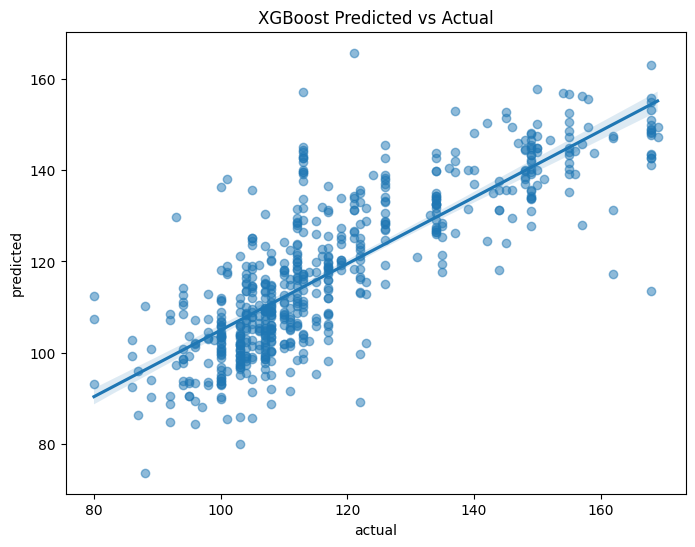

In [79]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [80]:
tt_bbd_snps = fs_data.iloc[:, 0:1000]
tt_bbd_snps.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr20_32404414,Chr14_11784839,Chr1_15174358,Chr16_37617327,Chr14_32962588,Chr18_45197353,Chr17_20583513,Chr3_40105409,Chr4_35874454,Chr12_16805346
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,0,2,0,1,0,0,1,1,0,0
s100,1,0,0,0,0,1,0,0,0,2,...,0,2,0,1,0,0,1,1,0,0
s1014,0,1,0,0,0,0,0,2,2,0,...,0,2,2,0,0,1,0,0,0,0
s1014,0,1,0,0,0,0,0,2,2,0,...,0,2,2,0,0,1,0,0,0,0
s1019,0,0,0,1,0,0,0,0,1,0,...,0,2,0,1,0,0,0,0,0,2


In [81]:
tt_bbd_snps_dupe = fs_data.iloc[:, 0:1000]
tt_bbd_snps_dupe.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr20_32404414,Chr14_11784839,Chr1_15174358,Chr16_37617327,Chr14_32962588,Chr18_45197353,Chr17_20583513,Chr3_40105409,Chr4_35874454,Chr12_16805346
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,0,2,0,1,0,0,1,1,0,0
s100,1,0,0,0,0,1,0,0,0,2,...,0,2,0,1,0,0,1,1,0,0
s1014,0,1,0,0,0,0,0,2,2,0,...,0,2,2,0,0,1,0,0,0,0
s1014,0,1,0,0,0,0,0,2,2,0,...,0,2,2,0,0,1,0,0,0,0
s1019,0,0,0,1,0,0,0,0,1,0,...,0,2,0,1,0,0,0,0,0,2


In [82]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,MD
Line,
s100,155.0
s100,115.0
s1014,108.0
s1014,104.0
s1019,113.0


# Run models

In [83]:
X_train, X_test, y_train, y_test = train_test_split(tt_bbd_snps, tt_y, test_size=0.1, random_state=42)

In [84]:
X_train.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr20_32404414,Chr14_11784839,Chr1_15174358,Chr16_37617327,Chr14_32962588,Chr18_45197353,Chr17_20583513,Chr3_40105409,Chr4_35874454,Chr12_16805346
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,0,0,0,0,0,0,1,1,0,...,0,2,0,1,0,1,0,1,0,0
s2863,0,0,0,0,0,0,0,1,1,0,...,0,1,0,0,0,0,1,1,2,0
s308,0,1,0,0,0,0,0,2,0,0,...,0,2,0,0,1,0,0,1,1,2
s2023,0,0,0,0,0,2,0,0,1,0,...,0,0,2,0,0,1,0,1,2,0
s614,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0


In [85]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [86]:
#Ran this is an isolated high mem job and got the bets params
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.6294227019323229), ('colsample_bytree', 0.7034144843091744), ('gamma', 2.7855912081079712e-06), ('learning_rate', 0.07470852873108728), ('max_delta_step', 0), ('max_depth', 1), ('min_child_weight', 7), ('n_estimators', 144), ('reg_alpha', 1.7825037491669726e-07), ('reg_lambda', 0.00033057492504522725), ('subsample', 0.821402142355175)])


In [87]:
tt_bbd_snps = tt_bbd_snps.to_numpy()
tt_y = tt_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, tt_bbd_snps, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -26.07469808131561
RMSE for dataset is:17.368901824697& mean of this fold is 113.95102040816326
this is 15.242427634682876% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -25.63294599845845
RMSE for dataset is:17.26570084649001& mean of this fold is 115.87755102040816
this is 14.89995317854897% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -28.511926393589874
RMSE for dataset is:19.39130398790929& mean of this fold is 116.64897959183673
this is 16.623637905587234% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -28.290050902155592
RMSE for dataset is:18.260790504705962& mean of this fold is 114.39183673469388
this is 15.963368563665743% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -27.55089693135599
RMSE for d

In [88]:
pickle.dump(best_xgbr_model, open("xgboost_onlysnps_xgbr_md.pickle.dat", "wb"))

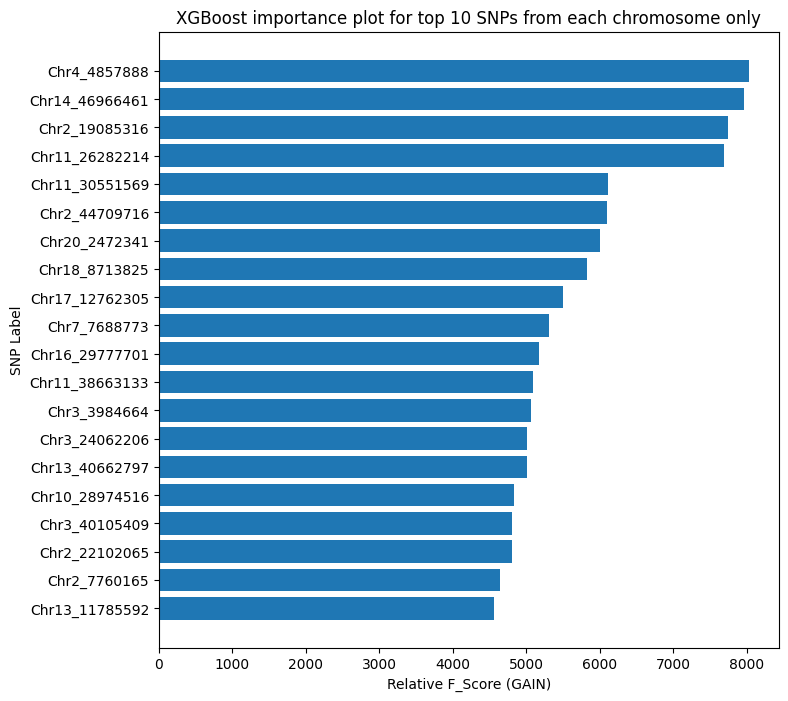

In [89]:
f_names = ['f' + str(i) for i in range(len(tt_bbd_snps_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[tt_bbd_snps_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome only')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome only.png')

In [90]:
explainer = shap.Explainer(best_xgbr_model)

In [91]:
shap_values = explainer(tt_bbd_snps_dupe)

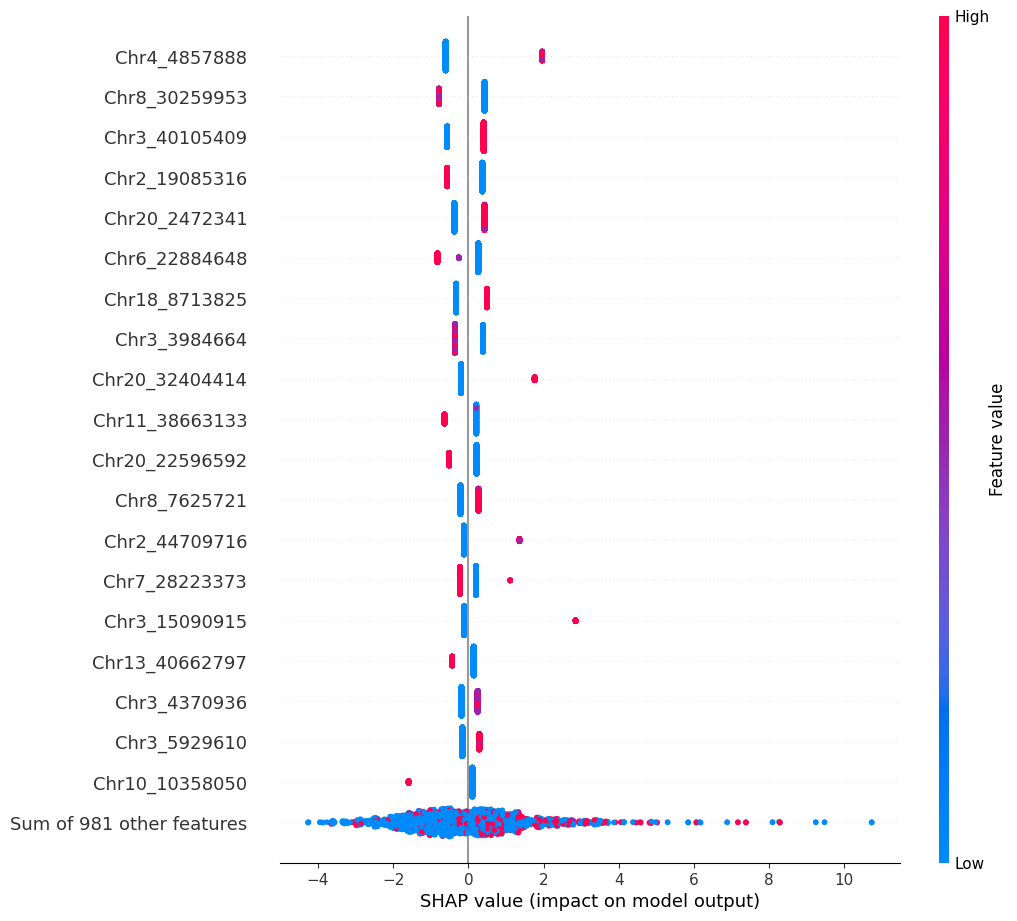

In [92]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [93]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [94]:
holdout_data = holdout_data.set_index('Line')

In [95]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [96]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [97]:
# Ensure both trainjg and holdout datasets have the same columns
tt_bbd_snps_dupe, X_holdout = tt_bbd_snps_dupe.align(X_holdout, join='inner', axis=1)

In [98]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 1000 entries, Chr13_18587942 to Chr12_16805346
dtypes: int64(1000)
memory usage: 4.7+ MB


In [99]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -26.07
RMSE of Holdout: 18.95
Mean of Holdout: 117.42
This is 16.14% of the mean pheno data
0 117.0 117.12796
1 148.0 115.49535
2 117.0 110.79113
3 121.0 117.07055
4 119.0 117.07055
5 94.0 114.61152


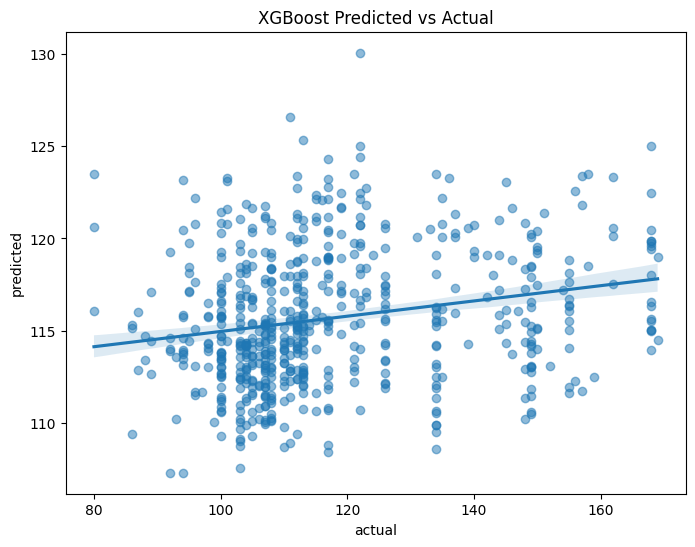

In [100]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [ ]:
#### RF models

In [101]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 37), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 16), ('n_estimators', 489)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 7), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 124)])

In [102]:
#tt_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, tt_bbd_snps, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -31.510881578804735
RMSE for dataset is:19.18198615273624& mean of this fold is 116.2530612244898
this is 16.500198748052732% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -36.345063498782295
RMSE for dataset is:19.46741738463751& mean of this fold is 117.02448979591837
this is 16.635336260458967% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -32.67983449682748
RMSE for dataset is:19.156718956042035& mean of this fold is 117.07755102040817
this is 16.362418575618108% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -28.146429192862428
RMSE for dataset is:19.26712609735843& mean of this fold is 116.78775510204082
this is 16.497556683510346% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -28.151108408447367
RMSE f

In [103]:
pickle.dump(best_rfr_model, open("xgboost_onlysnps_rfr_md.pickle.dat", "wb"))

R^2 Value of Holdout: -30.71
RMSE of Holdout: 19.09
Mean of Holdout: 117.42
This is 16.26% of the mean pheno data
0 117.0 120.92082248984099
1 148.0 112.82503202622593
2 117.0 113.50641218962522
3 121.0 121.6251526780199
4 119.0 121.6251526780199
5 94.0 115.51497656774684


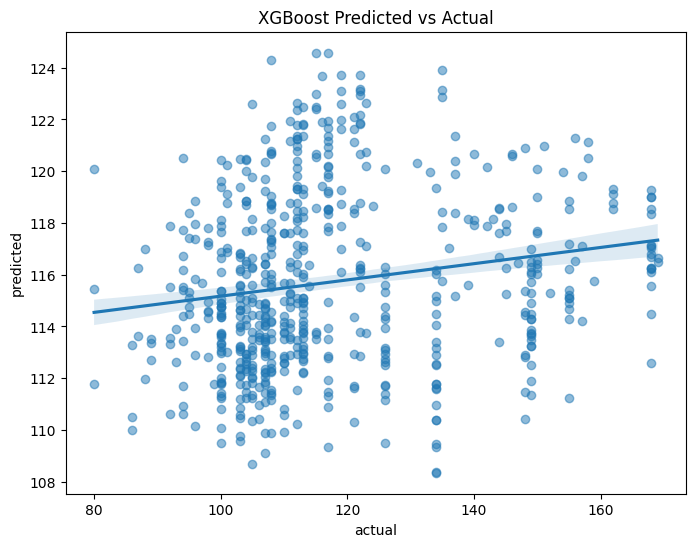

In [105]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [106]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2), ('kernel', 'poly')])


In [107]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, tt_bbd_snps, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -29.34035397037201
RMSE for dataset is:18.214594857033905& mean of this fold is 114.97551020408163
this is 15.842151797981138% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -35.80447063380833
RMSE for dataset is:20.19148810836562& mean of this fold is 117.59183673469387
this is 17.17082466695445% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -35.29677539287879
RMSE for dataset is:21.152883738491& mean of this fold is 117.68979591836735
this is 17.973422057051724% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -23.27250880682636
RMSE for dataset is:18.35136724208791& mean of this fold is 115.29387755102042
this is 15.917035346449316% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -25.227729201407115
RMSE for da

In [108]:
pickle.dump(best_svr_model, open("xgboost_onlysnps_svr_md.pickle.dat", "wb"))

R^2 Value of Holdout: -30.31
RMSE of Holdout: 19.98
Mean of Holdout: 117.42
This is 17.02% of the mean pheno data
0 117.0 114.18425292167409
1 148.0 106.60599938320169
2 117.0 110.81306483351705
3 121.0 112.34175140874889
4 119.0 112.34175140874889
5 94.0 109.93281549857433


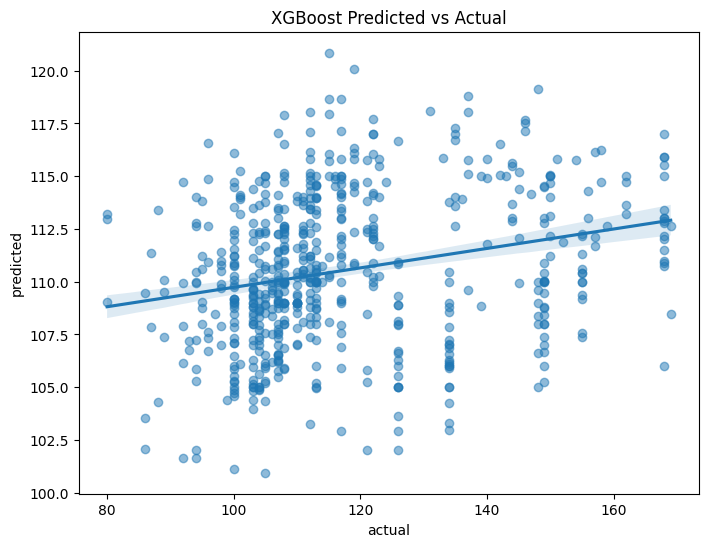

In [109]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [110]:
tt_loc= fs_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
tt_loc.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr3_40105409,Chr4_35874454,Chr12_16805346,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,1,0,0,1,0,0,0,0,0,1
s100,1,0,0,0,0,1,0,0,0,2,...,1,0,0,0,0,1,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,0,0,0,0,0,1,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,0,0,2,0,0,1,0,0,0,1


In [111]:
tt_loc_dupe= fs_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
tt_loc_dupe.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr3_40105409,Chr4_35874454,Chr12_16805346,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,1,0,0,1,0,0,0,0,0,1
s100,1,0,0,0,0,1,0,0,0,2,...,1,0,0,0,0,1,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,0,0,0,0,0,1,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,0,0,2,0,0,1,0,0,0,1


In [112]:
tt_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 1007 entries, Chr13_18587942 to landrace
dtypes: int64(1007)
memory usage: 18.9+ MB


In [113]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,MD
Line,
s100,155.0
s100,115.0
s1014,108.0
s1014,104.0
s1019,113.0


In [114]:
# Run models

In [115]:
X_train, X_test, y_train, y_test = train_test_split(tt_loc, tt_y, test_size=0.1, random_state=42)

In [116]:
X_train.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr3_40105409,Chr4_35874454,Chr12_16805346,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,0,0,0,0,0,0,1,1,0,...,1,0,0,0,1,0,0,0,1,0
s2863,0,0,0,0,0,0,0,1,1,0,...,1,2,0,0,0,1,0,0,1,0
s308,0,1,0,0,0,0,0,2,0,0,...,1,1,2,0,1,0,0,0,0,1
s2023,0,0,0,0,0,2,0,0,1,0,...,1,2,0,0,0,1,0,0,1,0
s614,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [117]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [118]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.9923710598637134), ('colsample_bytree', 0.7691228483798597), ('gamma', 2.3975408555863217e-06), ('learning_rate', 0.16392378219983655), ('max_delta_step', 3), ('max_depth', 3), ('min_child_weight', 7), ('n_estimators', 173), ('reg_alpha', 5.907964597205955e-07), ('reg_lambda', 8.231447520498255e-07), ('subsample', 0.6076467700135751)])


In [119]:
tt_loc = tt_loc.to_numpy()
tt_y = tt_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, tt_loc, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6620148322929966
RMSE for dataset is:9.030373928348116& mean of this fold is 116.11836734693877
this is 7.776869529492385% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6821938865823878
RMSE for dataset is:8.856310337706008& mean of this fold is 114.9795918367347
this is 7.702506328498303% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6504961385622559
RMSE for dataset is:8.819095969767114& mean of this fold is 116.06938775510204
this is 7.5981239673416425% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6406627568323804
RMSE for dataset is:9.42059030652554& mean of this fold is 115.65714285714286
this is 8.145273239337794% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4415821610811488
RMSE for datase

In [120]:
pickle.dump(best_xgbr_model, open("xgboost_onlyloc_xgbr_md.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top1_onlyloc_xgbr_bbd.pickle.dat", "rb"))

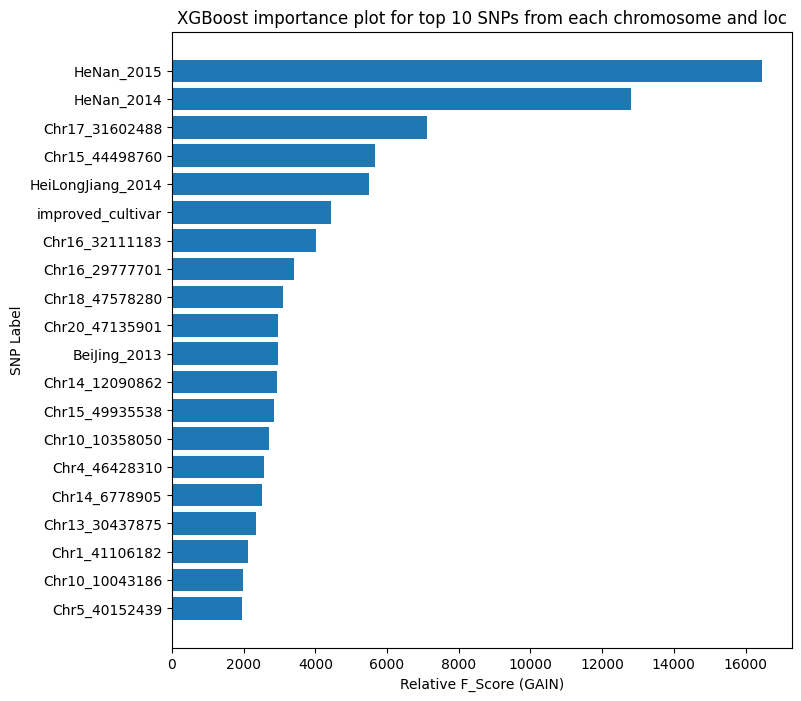

In [121]:
f_names = ['f' + str(i) for i in range(len(tt_loc_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[tt_loc_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome and loc')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome and loc.png')

In [122]:
explainer = shap.Explainer(best_xgbr_model)

In [123]:
shap_values = explainer(tt_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

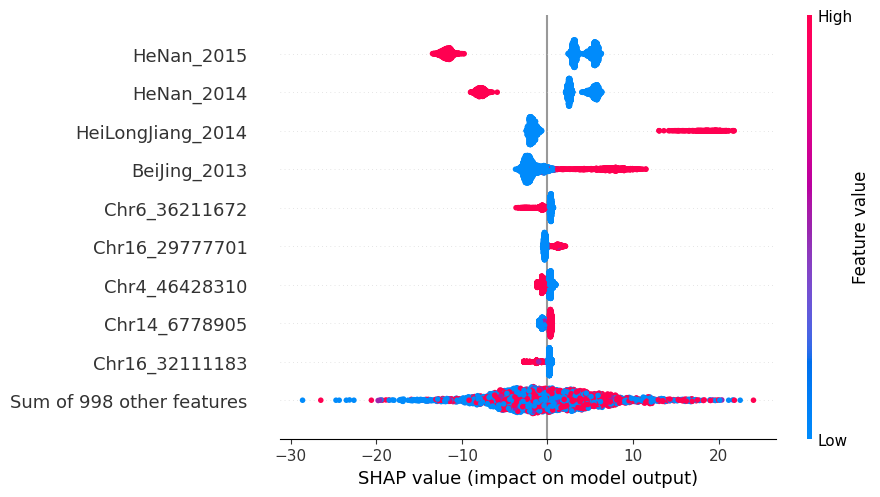

In [124]:
shap.plots.beeswarm(shap_values, show=False)

In [125]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [126]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [127]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [128]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [129]:
# Ensure both trainjg and holdout datasets have the same columns
tt_loc, X_holdout = tt_loc_dupe.align(X_holdout, join='inner', axis=1)

In [130]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 1007 entries, Chr13_18587942 to landrace
dtypes: int64(1007)
memory usage: 4.7+ MB


In [131]:
X_holdout.head()

,Chr13_18587942,Chr18_59868394,Chr11_15756244,Chr20_51595877,Chr17_13262697,Chr14_3319598,Chr3_38239686,Chr10_35378150,Chr8_47094728,Chr17_6437466,...,Chr3_40105409,Chr4_35874454,Chr12_16805346,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,0,0,0,1,0,0,0,2,...,1,0,0,0,1,0,0,0,0,1
s1014,0,1,0,0,0,0,0,2,2,0,...,0,0,0,1,0,0,0,0,0,1
s1019,0,0,0,1,0,0,0,0,1,0,...,0,0,2,0,1,0,0,0,0,1
s101,0,0,0,0,0,1,1,1,1,0,...,1,0,0,1,0,0,0,0,0,1
s101,0,0,0,0,0,1,1,1,1,0,...,1,0,0,0,0,0,0,1,0,1


In [132]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.58
RMSE of Holdout: 10.13
Mean of Holdout: 117.42
This is 8.63% of the mean pheno data
0 117.0 116.45299
1 148.0 144.10643
2 117.0 115.20261
3 121.0 112.365036
4 119.0 115.84617
5 94.0 99.24372


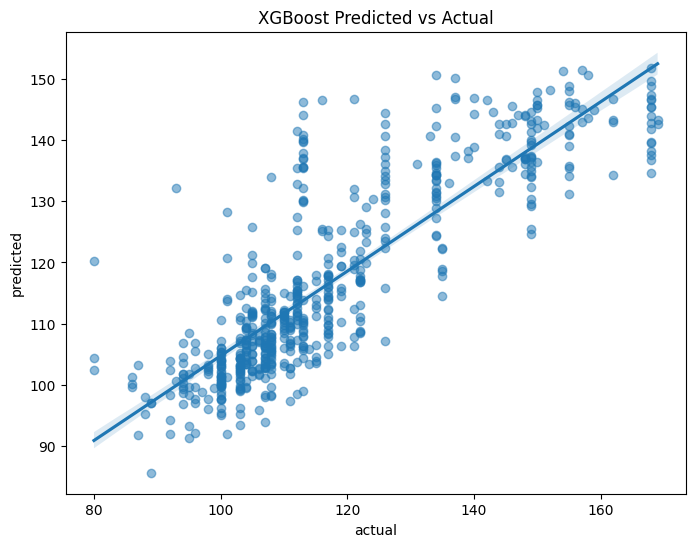

In [133]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [134]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 117.0 116.45299
1 148.0 144.10643
2 117.0 115.20261
3 121.0 112.365036
4 119.0 115.84617
5 94.0 99.24372


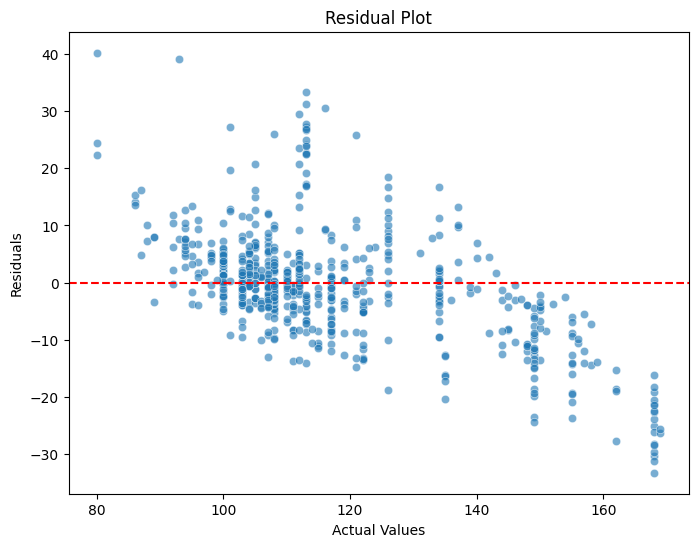

In [135]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [136]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.7457101485498447), ('min_samples_leaf', 1), ('min_samples_split', 19), ('n_estimators', 438)])


In [137]:
tt_loc = tt_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, tt_loc, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.459737328544086
RMSE for dataset is:14.331014918897086& mean of this fold is 115.04081632653062
this is 12.457330690543857% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.339570354068084
RMSE for dataset is:14.503377437029306& mean of this fold is 115.57142857142857
this is 12.54927590348642% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.384009467965599
RMSE for dataset is:14.163277188617807& mean of this fold is 114.91428571428571
this is 12.325079602228325% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.656477053733707
RMSE for dataset is:15.149817851785464& mean of this fold is 116.11428571428571
this is 13.047333287708938% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.412674187608699
RMSE fo

In [138]:
pickle.dump(best_rfr_model, open("xgboost_onlyloc_rfr_md.pickle.dat", "wb"))

R^2 Value of Holdout: -6.72
RMSE of Holdout: 15.98
Mean of Holdout: 117.42
This is 13.61% of the mean pheno data
0 117.0 118.61001647321454
1 148.0 121.94029408937187
2 117.0 113.45793972664357
3 121.0 125.03623102576996
4 119.0 123.67053579455728
5 94.0 112.02539115837735


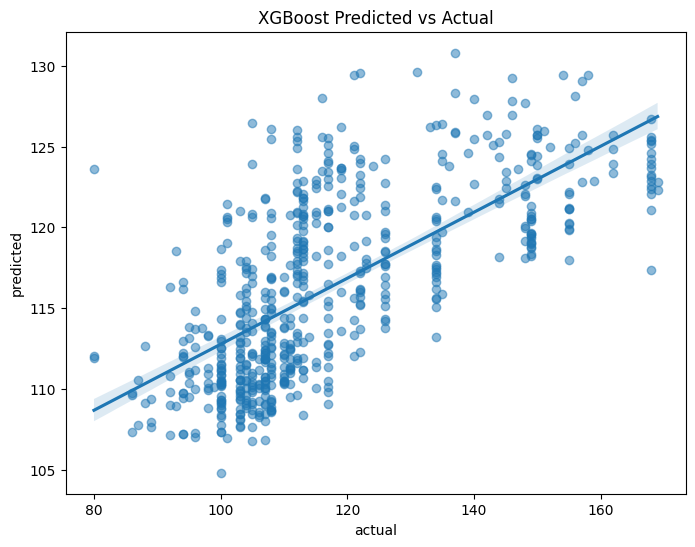

In [139]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [140]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [141]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, tt_loc, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.595198330042128
RMSE for dataset is:11.34142262034435& mean of this fold is 116.20408163265306
this is 9.759917604441046% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5339678390233281
RMSE for dataset is:12.57419101143294& mean of this fold is 114.59591836734694
this is 10.972634270555174% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5805032366814107
RMSE for dataset is:11.345219785855438& mean of this fold is 117.16326530612245
this is 9.683256741106366% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4820953488671291
RMSE for dataset is:12.607972215343912& mean of this fold is 115.68571428571428
this is 10.898469437812718% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5348915477649301
RMSE for da

In [142]:
pickle.dump(best_svr_model, open("xgboost_onlyloc_svr_md.pickle.dat", "wb"))

R^2 Value of Holdout: 0.50
RMSE of Holdout: 12.41
Mean of Holdout: 117.42
This is 10.57% of the mean pheno data
0 117.0 116.49994847999415
1 148.0 140.49991887315213
2 117.0 119.49979780851791
3 121.0 127.05618414293406
4 119.0 124.056107200994
5 94.0 92.74399246180877


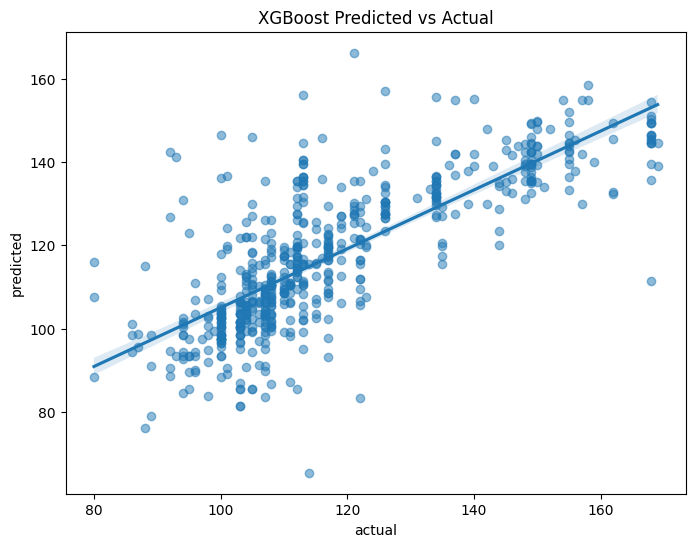

In [143]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)